In [4]:
import cv2 as cv
import numpy as np
import os
import math
from matplotlib import pyplot as plt
import scipy
import tqdm

# Question 1


image shape (256, 256)


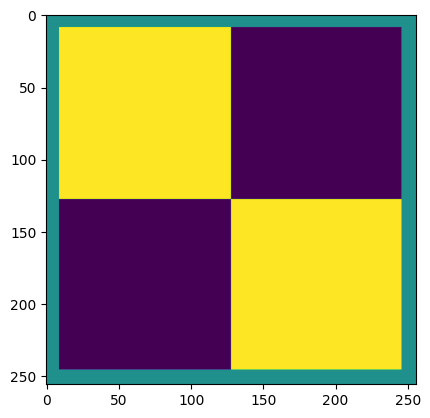

In [2]:
img = cv.imread("input/ps1-input0.png", cv.IMREAD_GRAYSCALE)
print("image shape", img.shape)
plt.imshow(img)
plt.show()

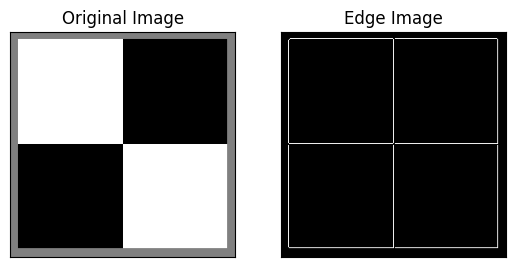

In [3]:
img_edges = cv.Canny(img,20,50)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

# Hough Transform

In [3]:
from tqdm import tqdm
import pickle

def hough_transform(img, img_edges, rho_jumps=1, theta_jumps=3, max_theta=180):

    max_d = np.sqrt(img.shape[0]**2 + img.shape[1]**2)

    d_values_range = np.arange(-max_d, max_d + rho_jumps, rho_jumps)
    theta_values = np.arange(0, max_theta, theta_jumps)

    coss = np.cos(np.deg2rad(theta_values))
    sins = np.sin(np.deg2rad(theta_values))

    H = np.zeros((len(d_values_range), len(theta_values))) 

    edges_indices = np.argwhere(img_edges > 0)
    print("Going thorugh the edges pixels")
    for edge_index in tqdm(edges_indices):
        y,x = edge_index
        d_values = x * coss + y * sins
        for theta_index, d in enumerate(d_values):
            d_index = np.argmin(np.abs(d_values_range - d))
            H[d_index, theta_index] += 1

    with open("accumulator.pkl", "wb") as file:
        pickle.dump(H, file)
    return H, d_values_range, theta_values



In [5]:
H, rho, theta = hough_transform(img, img_edges,theta_jumps=0.5,)

Going thorugh the edges pixels


100%|██████████| 1406/1406 [00:07<00:00, 198.00it/s]


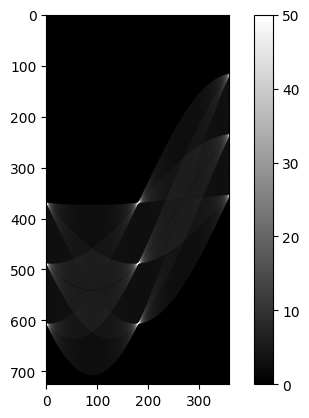

In [6]:
# plt.imshow(H), plt.xticks([]), plt.yticks([])
img12 = H.astype(np.uint8)
plt.imshow(img12, cmap="gray", vmin=0,vmax=50)
plt.colorbar()
plt.show()

In [2]:
# This is the old version. the new one is better.
def hough_peaks(accumulator, num_peaks=10,  threshold=0, nhood_size=3):
    peaks = []
    H_new = np.copy(accumulator)
    # Iterate until desired number of peaks found
    for i in range(num_peaks):
        # Find maximum peak value
        idx = np.argmax(H_new)
        r, c = np.unravel_index(idx, H_new.shape)
        
        # Check if peak value is above threshold
        if H_new[r, c] >= threshold:
            peaks.append((r, c))
            
            # Suppress the local neighborhood of the peak
            r_min = max(0, r - (nhood_size // 2))
            r_max = min(H_new.shape[0], r + (nhood_size // 2) + 1)
            c_min = max(0, c - (nhood_size // 2))
            c_max = min(H_new.shape[1], c + (nhood_size // 2) + 1)
            
            H_new[r_min:r_max, c_min:c_max] = 0
        
        else:
            break
    
    return np.array(peaks)
    

In [5]:
def hough_lines_draw(img, H, peaks, rho, theta, over_empty_image=False, img_edges=None):
    new_img = np.copy(img)
    if over_empty_image:
        new_img = np.zeros(img.shape)
    if img_edges is not None:
        new_img = np.copy(img_edges)


    peak_rho_indices = peaks[:,0]
    peak_theta_indices = peaks[:,1]

    peak_rho = rho[peak_rho_indices]
    peak_theta = theta[peak_theta_indices]

    x1 = peak_rho * np.cos(np.deg2rad(peak_theta))
    y1 = peak_rho * np.sin(np.deg2rad(peak_theta))

    direction = np.array([x1, -y1])
    
    pts2 = np.array([y1,x1]) - 1000 * direction
    pts1 = np.array([y1,x1]) + 1000 * direction

    for i in range(len(pts1[0])):
        pt1 = np.round([pts1[0,i], pts1[1,i]]).astype(np.int64)
        pt2 = np.round([pts2[0,i], pts2[1,i]]).astype(np.int64)
        new_img = cv.line(new_img, pt1[::-1],pt2[::-1],color=[255,0,0], thickness=1)
    

    plt.imshow(new_img, cmap="gray")




In [9]:
img = cv.imread("input/ps1-input0.png", cv.IMREAD_GRAYSCALE)
img_edges = cv.Canny(img,20,50)
H, rho, theta = hough_transform(img, img_edges, rho_jumps=0.5 ,theta_jumps=0.5,)

Going thorugh the edges pixels


100%|██████████| 1406/1406 [00:08<00:00, 164.35it/s]


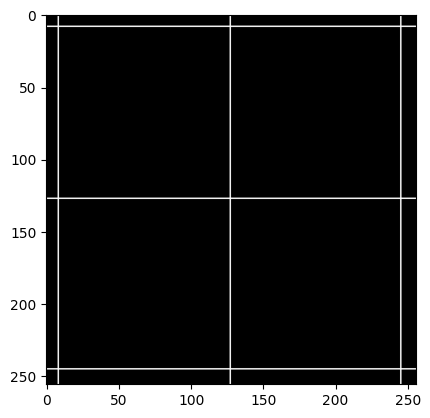

In [10]:

peaks = hough_peaks(H, num_peaks=6, threshold=100, nhood_size=5)
hough_lines_draw(img, H, peaks, rho, theta, over_empty_image=True)

### Now we add noise


[[ 88 118 114 ... 128 155 124]
 [ 87 109 114 ... 117 133 109]
 [102 115 121 ... 121 127 109]
 ...
 [ 64  75  90 ... 113 120 106]
 [ 41  61  80 ... 110 117 105]
 [ 34  59  89 ... 102 109  99]]


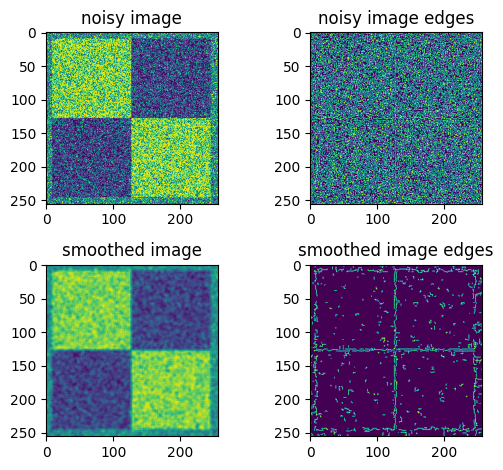

In [11]:
img_with_noise = cv.imread("input/ps1-input0-noise.png", cv.IMREAD_GRAYSCALE)
plt.subplot(221)
plt.title("noisy image")
plt.imshow(img_with_noise)
img_with_noise_edges = cv.Canny(img_with_noise, 220,150)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_with_noise_edges)


# kernel = cv.getGaussianKernel(49, 5).reshape(7,7)
# kernel = np.ones((5,5),np.float32)/25
# print(kernel)

# img_smooth = cv.filter2D(img_with_noise,-1,kernel)
img_smooth = cv.GaussianBlur(img_with_noise, (5,5), 20)
print(img_smooth)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth)
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 150,200)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges)
plt.tight_layout()

plt.show()

In [12]:
H, rho, theta = hough_transform(img_smooth, img_smooth_edges, rho_jumps=0.5 ,theta_jumps=0.5,)


Going thorugh the edges pixels


100%|██████████| 3444/3444 [00:17<00:00, 201.71it/s]


#### The lines of the noisy image

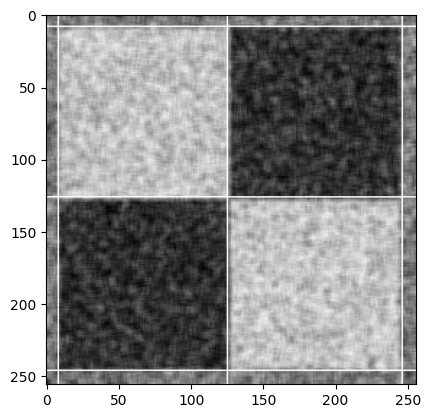

In [13]:

peaks = hough_peaks(H, num_peaks=10, threshold=60, nhood_size=20)
hough_lines_draw(img_smooth, H, peaks, rho, theta, over_empty_image=False)

### 4. Circles and stuff

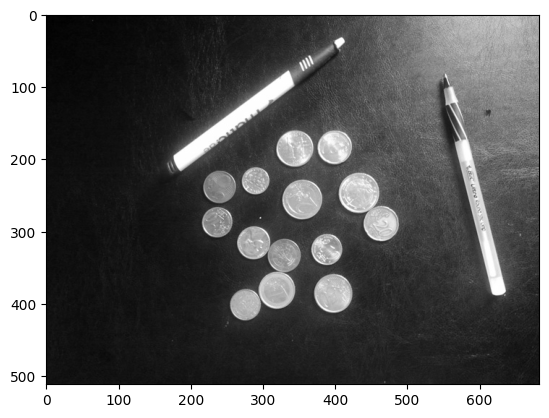

In [14]:
img = cv.imread("input/ps1-input1.png", cv.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

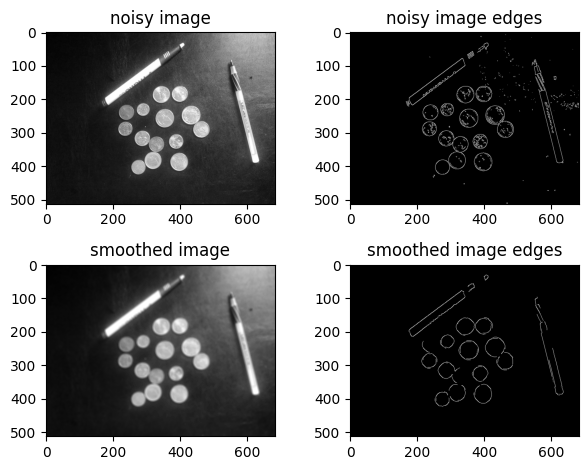

In [15]:
plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (7,7), 20)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 100,200)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

In [16]:
H, rho, theta = hough_transform(img_smooth, img_smooth_edges, rho_jumps=0.5, theta_jumps=0.5)

Going thorugh the edges pixels


100%|██████████| 3653/3653 [00:23<00:00, 152.26it/s]


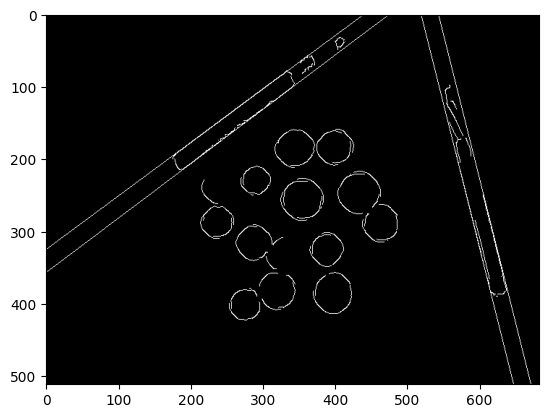

In [17]:
peaks= hough_peaks(H, num_peaks=10,threshold=50, nhood_size=20)
hough_lines_draw(img_smooth, H, peaks, rho, theta, img_edges=img_smooth_edges)


In [1]:
def hough_circles_acc(img_edges, radius=20, estimate_gradient=False, leave=True):

    # max_d = np.sqrt(img_edges.shape[0]**2 + img_edges.shape[1]**2)

    a_values = np.arange(img_edges.shape[1])
    b_values = np.arange(img_edges.shape[0])

    H = np.zeros((len(a_values), len(b_values))) 

    edges_indices = np.argwhere(img_edges > 0)
    thetas = np.arange(360)
    thetas_in_rad = np.deg2rad(thetas)
    coss = np.cos(thetas_in_rad)
    sins = np.sin(thetas_in_rad)


    for y,x in tqdm(edges_indices, leave=leave):
        a = x - radius * coss
        b = y + radius * sins
        mask =  (0 <= a ) & (a < H.shape[0]) &  (0 <= b) & (b < H.shape[1])
        a =  a[mask].astype(int)
        b = b[mask].astype(int)
        H[a,b] +=1

    return H, a_values, b_values


def find_circles(img_edges, radii, estimate_gradient=False):
    centers = []
    for radius in radii:
        H, a_values, b_values = hough_circles_acc(img_edges, radius, estimate_gradient)
        centers.append(hough_peaks(H,num_peaks=50, threshold=50, nhood_size=3))

    return centers, radii, H


In [19]:
H, a_values, b_values = hough_circles_acc(img_smooth_edges)

100%|██████████| 3653/3653 [00:00<00:00, 25461.29it/s]


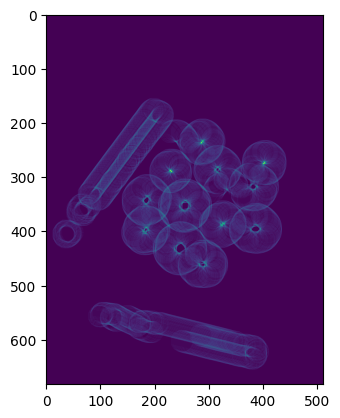

In [20]:
plt.imshow(H)
centers = hough_peaks(H,num_peaks=50, threshold=50,nhood_size=3)


### 6. Realistic images

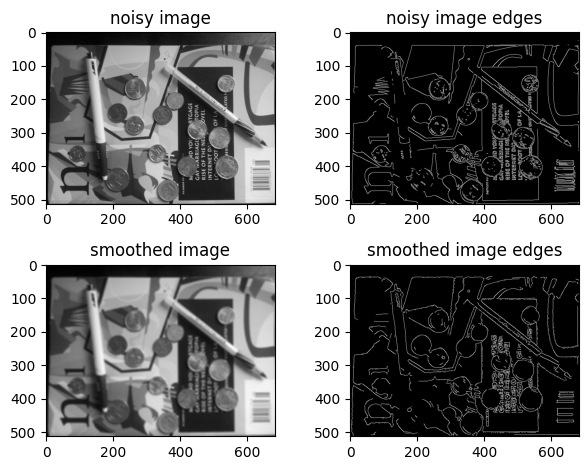

In [21]:
img = cv.imread("input/ps1-input2.png", cv.IMREAD_GRAYSCALE)
# plt.imshow(img, cmap="gray")

plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (7,7), 25)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 60,90)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

#### Find lines of the pens

In [22]:
H, rho, theta = hough_transform(img_smooth, img_smooth_edges, rho_jumps=0.5, theta_jumps=0.5)

Going thorugh the edges pixels


100%|██████████| 17738/17738 [02:07<00:00, 139.15it/s]


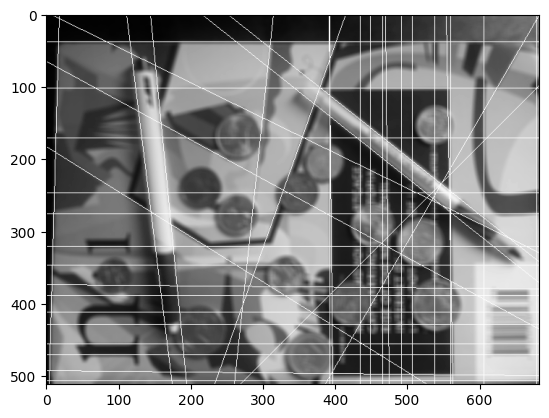

In [23]:
peaks = hough_peaks(H, num_peaks=40, threshold=0, nhood_size=50)
hough_lines_draw(img_smooth, H, peaks, rho, theta)

In [6]:
def hough_lines_draw_find_pens(img, H, peaks, rho, theta, over_empty_image=False, img_edges=None):
    new_img = np.copy(img)
    if over_empty_image:
        new_img = np.zeros(img.shape)
    if img_edges is not None:
        new_img = np.copy(img_edges)


    peak_rho_indices = peaks[:,0]
    peak_theta_indices = peaks[:,1]

    peak_rho = rho[peak_rho_indices]
    peak_theta = theta[peak_theta_indices]

    x1 = peak_rho * np.cos(np.deg2rad(peak_theta))
    y1 = peak_rho * np.sin(np.deg2rad(peak_theta))


    direction = np.array([x1, -y1])
    
    pts2 = np.array([y1,x1]) - 1000 * direction
    pts1 = np.array([y1,x1]) + 1000 * direction

    # find lines that are vertical or horizontal
    atol = 0.05
    mask = np.isclose(np.sin(np.deg2rad(peak_theta)),0,atol=atol) | np.isclose(np.cos(np.deg2rad(peak_theta)), 0,atol=atol)  
    indices_to_remove = np.where(mask)[0]

    # find lines that dont have a close parallel
    relevant_indices = np.array(list(set(range(len(peak_theta))) - set(indices_to_remove)))
    
    parallel_line_atol = 0.03
    for i in relevant_indices:
        is_relevant = False
        for j in relevant_indices:
            rad_i = np.deg2rad(peak_theta[i])
            rad_j = np.deg2rad(peak_theta[j])

            if i != j and np.isclose(np.sin(rad_i), np.sin(rad_j), atol=parallel_line_atol) and np.isclose(np.cos(rad_i), np.cos(rad_j), atol=parallel_line_atol):
                is_relevant = True

        if not is_relevant:
            indices_to_remove = np.append(indices_to_remove, i)  

    for i in range(len(pts1[0])):
        if i not in indices_to_remove:
            pt1 = np.round([pts1[0,i], pts1[1,i]]).astype(np.int64)
            pt2 = np.round([pts2[0,i], pts2[1,i]]).astype(np.int64)
            new_img = cv.line(new_img, pt1[::-1],pt2[::-1],color=[255,0,0], thickness=1)
    

    plt.imshow(new_img, cmap="gray")

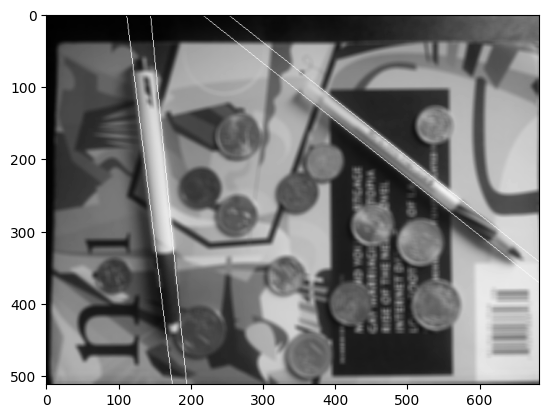

In [25]:
peaks = hough_peaks(H, num_peaks=40, threshold=0, nhood_size=50)
hough_lines_draw_find_pens(img_smooth, H, peaks, rho, theta)

### 7. Find circles now

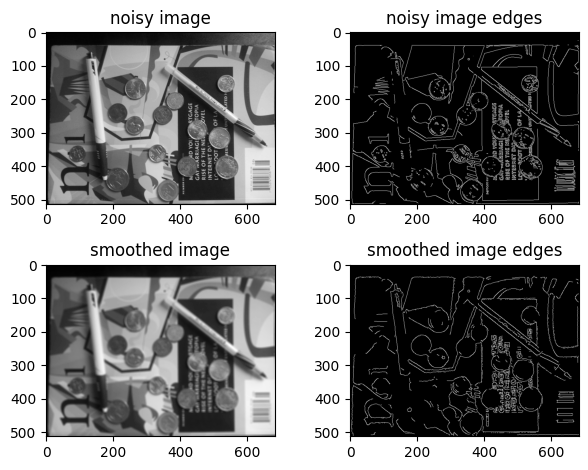

In [26]:
img = cv.imread("input/ps1-input2.png", cv.IMREAD_GRAYSCALE)
# plt.imshow(img, cmap="gray")

plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (7,7), 30)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 70,100)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

In [27]:
centers, radii, H = find_circles(img_edges, [20,25,30], estimate_gradient=False)

100%|██████████| 21795/21795 [00:00<00:00, 25651.07it/s]


radius is  20


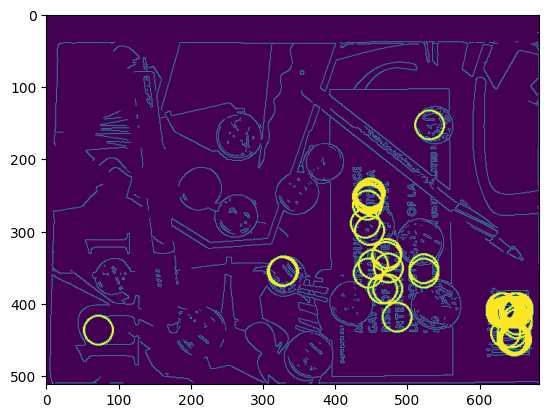

radius is  25


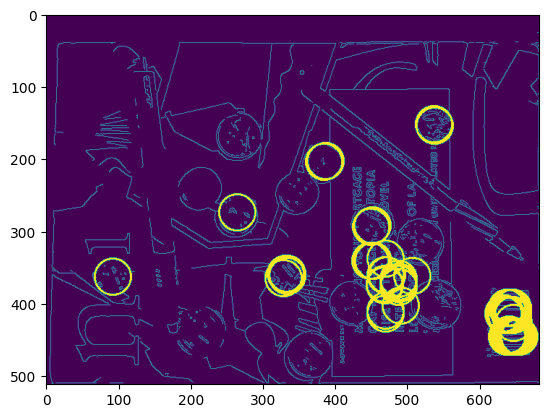

radius is  30


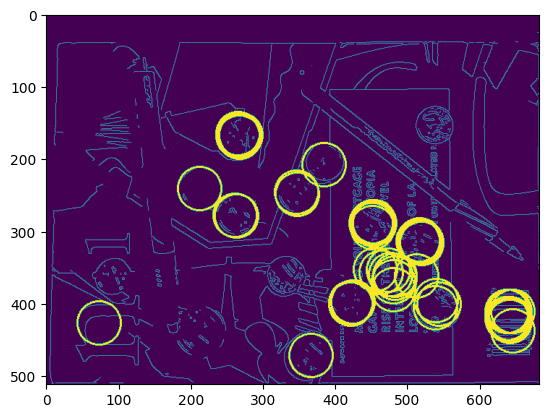

In [28]:
for i,center_arr in enumerate(centers):
    print("radius is ", radii[i])
    img_edges_copy = np.copy(img_edges)
    img_edges_copy = img_edges_copy // 2
    for center in center_arr:
        pixel_index = center[::-1]
        # img_edges_copy[pixel_index[0]][pixel_index[1]] = 255
        img_edges_copy = cv.circle(img_edges_copy, center, radii[i],thickness=2, color=255)
        # print(img_edges_copy[pixel_index])
    plt.imshow(img_edges_copy, vmin=0, vmax=255)
    plt.show() 

### Try hadar stuff....


In [11]:
from scipy import ndimage
def hough_peaks_local_max(accumulator, num_peaks=10,  threshold=0, filter_size=20):
    max_filter = ndimage.maximum_filter(accumulator, size=filter_size)
    min_filter = ndimage.minimum_filter(accumulator, size=filter_size)

    mask = (max_filter == accumulator) & (max_filter != min_filter) & (accumulator >= threshold)
    indices = np.argwhere(mask)
    values = [accumulator[index[0],index[1]] for index in indices]
    sorted_indices = np.argsort(values)[::-1]
    peaks = indices[sorted_indices][:num_peaks]
    return peaks

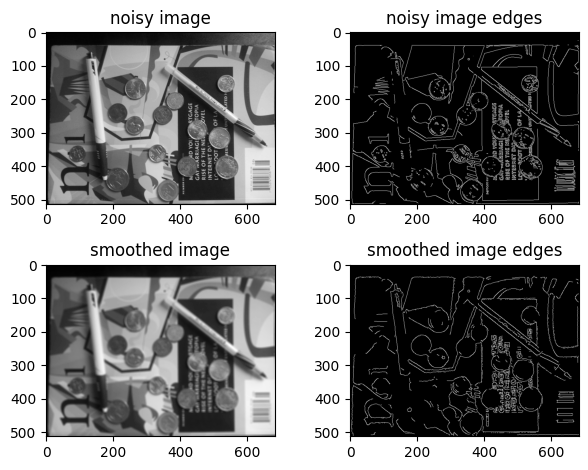

In [9]:
img = cv.imread("input/ps1-input2.png", cv.IMREAD_GRAYSCALE)
# plt.imshow(img, cmap="gray")

plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (7,7), 30)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 70,100)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

In [31]:
radii = [20,25,30]
results = []
for radius in radii:
    H, a_values, b_values = hough_circles_acc(img_smooth_edges, radius)
    results.append((H, a_values, b_values))
    centers.append(hough_peaks_local_max(H,num_peaks=5, threshold=100, filter_size=20))


100%|██████████| 16419/16419 [00:00<00:00, 20597.29it/s]


radius is  20


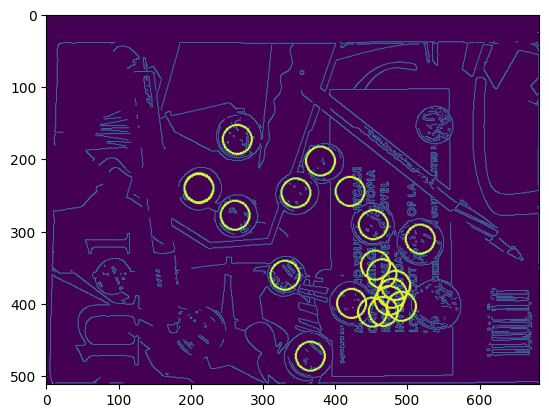

radius is  25


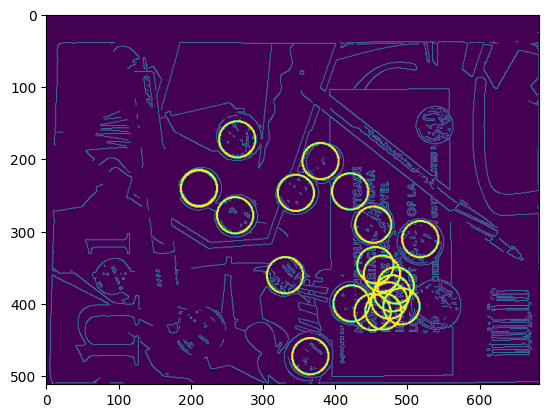

radius is  30


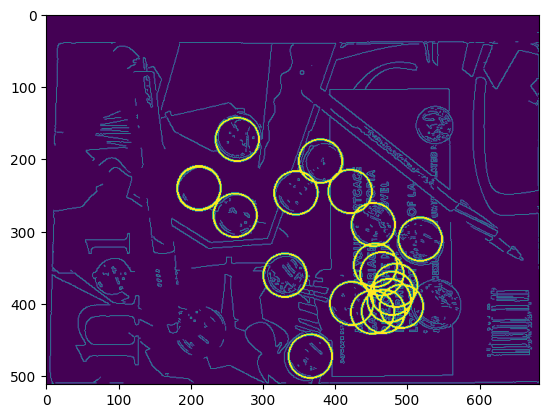

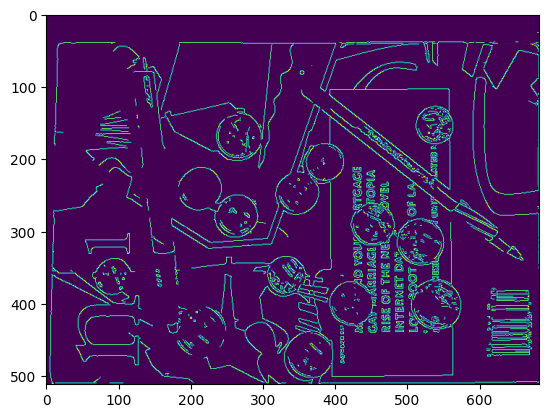

In [32]:
centers = []
for i,result in enumerate(results):
    centers.append(hough_peaks_local_max(H,num_peaks=20, threshold=0, filter_size=20))
for i,center_arr in enumerate(centers):
    print("radius is ", radii[i])
    img_edges_copy = np.copy(img_edges)
    img_edges_copy = img_edges_copy // 2
    for center in center_arr:
        pixel_index = center[::-1]
        # img_edges_copy[pixel_index[0]][pixel_index[1]] = 255
        img_edges_copy = cv.circle(img_edges_copy, center, radii[i],thickness=2, color=255)
        # print(img_edges_copy[pixel_index])
    plt.imshow(img_edges_copy, vmin=0, vmax=255)
    plt.show() 

plt.imshow(img_edges)
plt.show()


In [25]:
def hough_draw_circles(img, peaks, radii):
    for i, center in enumerate(peaks):
        img = cv.circle(img, center, radii[i],thickness=20, color=255)
    
def find_circles_range(img_edges, num_peaks=10, radius_range=[20,30], nhood_size=30):
    radii = np.arange(*radius_range)
    accumulators = [hough_circles_acc(img_edges, radius, leave=False)[0] for radius in tqdm(radii)]
    accumulators_normalized = accumulators / radii[:,None,None]  
    peakss = np.array([hough_peaks_local_max(acc,num_peaks=num_peaks, threshold=0, filter_size=30) for acc in accumulators_normalized])
    # valuess = np.array([accumulators_normalized[i][peaks] for i,peaks in enumerate(peakss)])
    valuess = np.array([[acc[peak[0]][peak[1]] for peak in [peaks for peaks in peakss[i]]] for i,acc in enumerate(accumulators_normalized)])

    peaks = peakss.reshape(-1,2)
    values = valuess.reshape(-1)
    radiis = np.repeat(radii, num_peaks)

    indices_to_rmeove = []
    for i in range(len(peaks)):
        for j in range(i+1, len(peaks)):
            if np.linalg.norm([peaks[i], peaks[j]]) <= nhood_size: # close peaks (close positions in image)
                if values[i] <= values[j]:
                    indices_to_rmeove.append(i)
                else:
                    indices_to_rmeove.append(j)
    

    sorted_indices = np.argsort(values)
    values = values[sorted_indices]
    peaks = peaks[sorted_indices]
    radiis = radiis[sorted_indices]

    print(values)

    
    indices_to_take = np.setdiff1d(np.arange(len(peaks)), indices_to_rmeove)
    # return peaks[indices_to_take][:num_peaks], radiis[indices_to_take][:num_peaks]
    return peaks[indices_to_take], radiis[indices_to_take]
    # Remove duplicates (close pixels- just take the one with higher normalized value)





















































































































































































































































































































































































































































100%|██████████| 15/15 [00:48<00:00,  3.26s/it]


[1.47058824 1.47058824 1.5        1.5        1.5        1.55882353
 1.5625     1.59375    1.60606061 1.61764706 1.61764706 1.625
 1.625      1.625      1.66666667 1.67647059 1.6875     1.71875
 1.71875    1.72       1.72727273 1.72727273 1.73076923 1.73333333
 1.73529412 1.74193548 1.74193548 1.74193548 1.75757576 1.75757576
 1.75757576 1.76       1.76190476 1.76190476 1.76190476 1.76666667
 1.76666667 1.76923077 1.76923077 1.76923077 1.77272727 1.77272727
 1.77272727 1.77419355 1.77419355 1.77419355 1.77419355 1.77419355
 1.78125    1.80769231 1.80952381 1.8125     1.81481481 1.81818182
 1.81818182 1.82142857 1.82758621 1.82758621 1.83333333 1.83333333
 1.83333333 1.84       1.84       1.84       1.84       1.84375
 1.84615385 1.85       1.85185185 1.85185185 1.86206897 1.86206897
 1.86206897 1.86666667 1.86956522 1.88       1.88       1.88235294
 1.88461538 1.88461538 1.88888889 1.89285714 1.9        1.9
 1.9        1.9        1.90625    1.90909091 1.90909091 1.90909091
 1.91176471 1

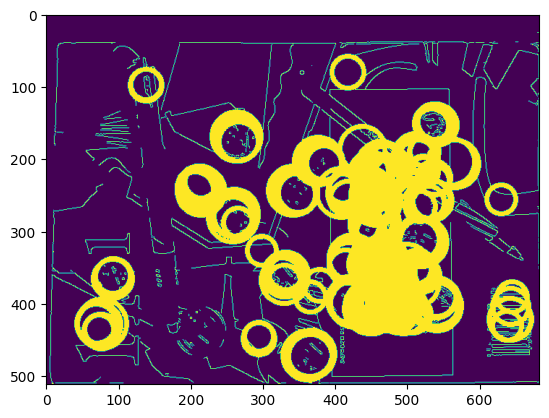

In [27]:
peaks, radii = find_circles_range(img_smooth_edges, num_peaks=20, radius_range=[20,35])

img_cpy = np.copy(img_edges)
for i,peak in enumerate(peaks):
    img_cpy = cv.circle(img_cpy,peak, radii[i], color=255, thickness=5)

plt.imshow(img_cpy)
plt.show()

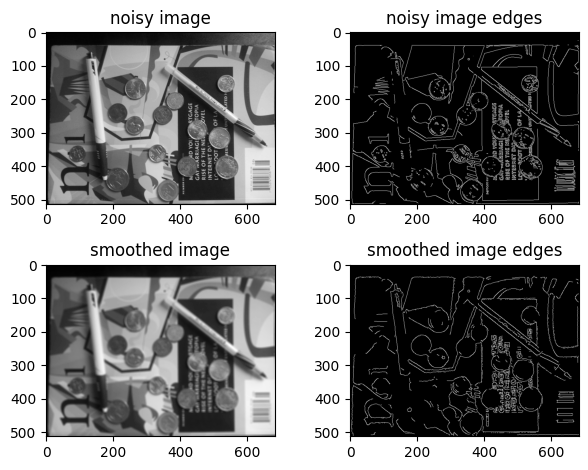

In [ ]:
img = cv.imread("input/ps1-input2.png", cv.IMREAD_GRAYSCALE)
# plt.imshow(img, cmap="gray")

plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (7,7), 30)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 70,100)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

In [ ]:
find_circles_range(img_smooth_edges, [20,30])

### 8. Distorted images


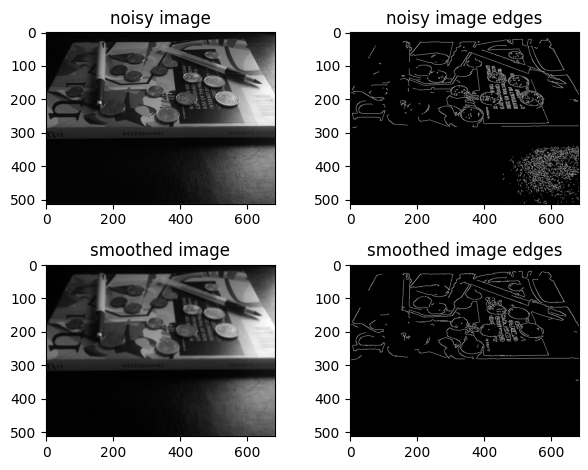

In [ ]:
img = cv.imread("input/ps1-input3.png", cv.IMREAD_GRAYSCALE)
# plt.imshow(img, cmap="gray")

plt.subplot(221)
plt.title("noisy image")
plt.imshow(img, cmap="gray")

img_edges = cv.Canny(img, 150,200)
plt.subplot(222)
plt.title("noisy image edges")
plt.imshow(img_edges, cmap="gray")

img_smooth = cv.GaussianBlur(img, (5,5), 10)
plt.subplot(223)
plt.title("smoothed image")
plt.imshow(img_smooth, cmap="gray")
plt.tight_layout()

img_smooth_edges = cv.Canny(img_smooth, 70,100)
plt.subplot(224)
plt.title("smoothed image edges")
plt.imshow(img_smooth_edges, cmap="gray")
plt.tight_layout()

plt.show()

In [ ]:
radii = [20,25]
results = []
for radius in radii:
    H, a_values, b_values = hough_circles_acc(img_smooth_edges, radius)
    results.append((H, a_values, b_values))
    # centers.append(hough_peaks_local_max(H,num_peaks=5, threshold=120, filter_size=20))

Going thorugh the edges pixels


  0%|          | 0/10099 [00:00<?, ?it/s]

100%|██████████| 10099/10099 [01:38<00:00, 102.47it/s]


Going thorugh the edges pixels


100%|██████████| 10099/10099 [00:46<00:00, 215.62it/s]


(683, 512)
(683, 512)
radius is  20


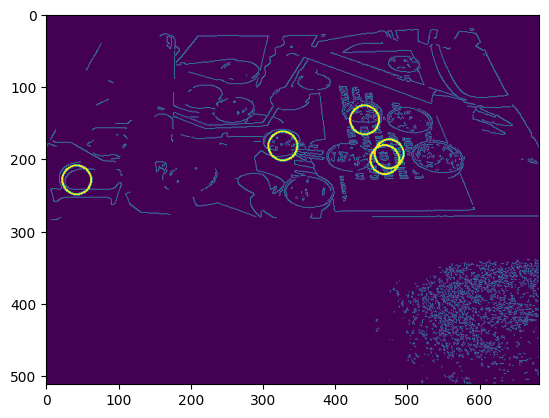

radius is  25


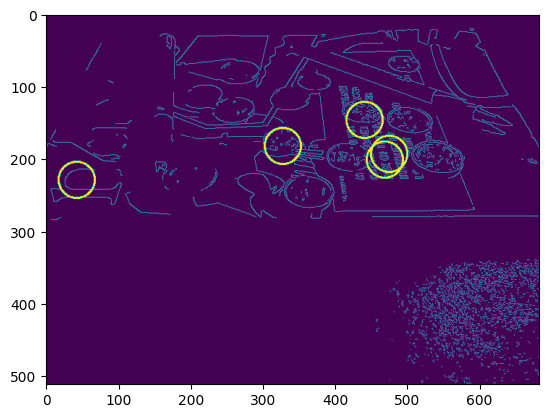

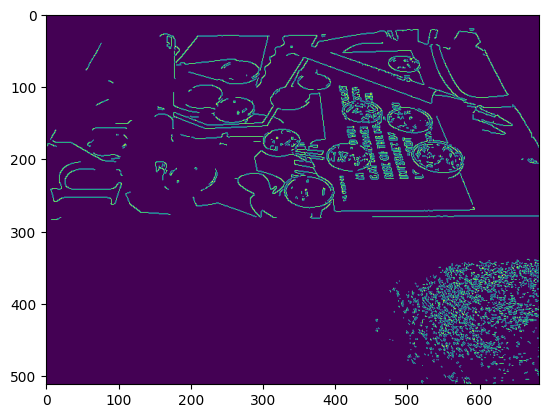

In [ ]:
centers = []
for i,result in enumerate(results):
    centers.append(hough_peaks_local_max(H,num_peaks=20, threshold=100, filter_size=40))
for i,center_arr in enumerate(centers):
    print("radius is ", radii[i])
    img_edges_copy = np.copy(img_edges)
    img_edges_copy = img_edges_copy // 2
    for center in center_arr:
        pixel_index = center[::-1]
        # img_edges_copy[pixel_index[0]][pixel_index[1]] = 255
        img_edges_copy = cv.circle(img_edges_copy, center, radii[i],thickness=2, color=255)
        # print(img_edges_copy[pixel_index])
    plt.imshow(img_edges_copy, vmin=0, vmax=255)
    plt.show() 

plt.imshow(img_edges)
plt.show()
